<a href="https://colab.research.google.com/github/jack1-spec/Hello-World/blob/master/_downloads/770632dd3941d2a51b831c52ded57aa2/trainingyt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

[Introduction](introyt1_tutorial.html) \|\|
[Tensors](tensors_deeper_tutorial.html) \|\|
[Autograd](autogradyt_tutorial.html) \|\| [Building
Models](modelsyt_tutorial.html) \|\| [TensorBoard
Support](tensorboardyt_tutorial.html) \|\| **Training Models** \|\|
[Model Understanding](captumyt.html)

Training with PyTorch
=====================

Follow along with the video below or on
[youtube](https://www.youtube.com/watch?v=jF43_wj_DCQ).



In [2]:
# Run this cell to load the video
from IPython.display import display, HTML
html_code = """
<div style="margin-top:10px; margin-bottom:10px;">
  <iframe width="560" height="315" src="https://www.youtube.com/embed/jF43_wj_DCQ" frameborder="0" allow="accelerometer; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
</div>
"""
display(HTML(html_code))



Introduction
------------

In past videos, we've discussed and demonstrated:

-   Building models with the neural network layers and functions of the
    torch.nn module
-   The mechanics of automated gradient computation, which is central to
    gradient-based model training
-   Using TensorBoard to visualize training progress and other
    activities

In this video, we'll be adding some new tools to your inventory:

-   We'll get familiar with the dataset and dataloader abstractions, and
    how they ease the process of feeding data to your model during a
    training loop
-   We'll discuss specific loss functions and when to use them
-   We'll look at PyTorch optimizers, which implement algorithms to
    adjust model weights based on the outcome of a loss function

Finally, we'll pull all of these together and see a full PyTorch
training loop in action.

Dataset and DataLoader
----------------------

The `Dataset` and `DataLoader` classes encapsulate the process of
pulling your data from storage and exposing it to your training loop in
batches.

The `Dataset` is responsible for accessing and processing single
instances of data.

The `DataLoader` pulls instances of data from the `Dataset` (either
automatically or with a sampler that you define), collects them in
batches, and returns them for consumption by your training loop. The
`DataLoader` works with all kinds of datasets, regardless of the type of
data they contain.

For this tutorial, we'll be using the Fashion-MNIST dataset provided by
TorchVision. We use `torchvision.transforms.v2.Normalize()` to
zero-center and normalize the distribution of the image tile content,
and download both training and validation data splits.


In [3]:
import torch
import torchvision
from torchvision.transforms import v2

# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

# Create datasets for training & validation, download if necessary
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

# Create data loaders for our datasets; shuffle for training, not for validation
training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Report split sizes
print(f'Training set has {len(training_set)} instances')
print(f'Validation set has {len(validation_set)} instances')

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.8MB/s]

Training set has 60000 instances
Validation set has 10000 instances


As always, let's visualize the data as a sanity check:


Shirt  Sandal  Trouser  Pullover


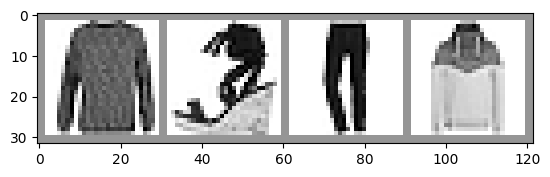

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

The Model
=========

The model we'll use in this example is a variant of LeNet-5 - it should
be familiar if you've watched the previous videos in this series.


In [5]:
import torch.nn as nn
import torch.nn.functional as F

# PyTorch models inherit from torch.nn.Module
class GarmentClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = GarmentClassifier()

Loss Function
=============

For this example, we'll be using a cross-entropy loss. For demonstration
purposes, we'll create batches of dummy output and label values, run
them through the loss function, and examine the result.


In [6]:
loss_fn = torch.nn.CrossEntropyLoss()

# NB: Loss functions expect data in batches, so we're creating batches of 4
# Represents the model's confidence in each of the 10 classes for a given input
dummy_outputs = torch.rand(4, 10)
# Represents the correct class among the 10 being tested
dummy_labels = torch.tensor([1, 5, 3, 7])

print(dummy_outputs)
print(dummy_labels)

loss = loss_fn(dummy_outputs, dummy_labels)
print(f'Total loss for this batch: {loss.item()}')

tensor([[0.9162, 0.1856, 0.8791, 0.6635, 0.5000, 0.7744, 0.9274, 0.5358, 0.0628,
         0.9464],
        [0.6206, 0.0744, 0.6886, 0.4380, 0.3054, 0.9039, 0.2631, 0.8528, 0.6655,
         0.9799],
        [0.4504, 0.5071, 0.3616, 0.5657, 0.0163, 0.4348, 0.4618, 0.9318, 0.8856,
         0.0457],
        [0.7476, 0.1773, 0.0708, 0.3896, 0.6653, 0.9158, 0.0511, 0.5072, 0.5562,
         0.0678]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.3280081748962402


Optimizer
=========

For this example, we'll be using simple [stochastic gradient
descent](https://pytorch.org/docs/stable/optim.html) with momentum.

It can be instructive to try some variations on this optimization
scheme:

-   Learning rate determines the size of the steps the optimizer takes.
    What does a different learning rate do to the your training results,
    in terms of accuracy and convergence time?
-   Momentum nudges the optimizer in the direction of strongest gradient
    over multiple steps. What does changing this value do to your
    results?
-   Try some different optimization algorithms, such as averaged SGD,
    Adagrad, or Adam. How do your results differ?


In [7]:
# Optimizers specified in the torch.optim package
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

The Training Loop
=================

Below, we have a function that performs one training epoch. It
enumerates data from the DataLoader, and on each pass of the loop does
the following:

-   Gets a batch of training data from the DataLoader
-   Zeros the optimizer's gradients
-   Performs an inference - that is, gets predictions from the model for
    an input batch
-   Calculates the loss for that set of predictions vs. the labels on
    the dataset
-   Calculates the backward gradients over the learning weights
-   Tells the optimizer to perform one learning step - that is, adjust
    the model's learning weights based on the observed gradients for
    this batch, according to the optimization algorithm we chose
-   It reports on the loss for every 1000 batches.
-   Finally, it reports the average per-batch loss for the last 1000
    batches, for comparison with a validation run


In [8]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss

Per-Epoch Activity
==================

There are a couple of things we'll want to do once per epoch:

-   Perform validation by checking our relative loss on a set of data
    that was not used for training, and report this
-   Save a copy of the model

Here, we'll do our reporting in TensorBoard. This will require going to
the command line to start TensorBoard, and opening it in another browser
tab.


In [9]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter(f'runs/fashion_trainer_{timestamp}')
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print(f'EPOCH {epoch_number + 1}:')

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'model_{timestamp}_{epoch_number}'
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 1.7739309054911137
  batch 2000 loss: 0.8639096244163811
  batch 3000 loss: 0.7166385020567104
  batch 4000 loss: 0.6637593037094921
  batch 5000 loss: 0.6154944818313234
  batch 6000 loss: 0.5578063407649752
  batch 7000 loss: 0.5254874718680512
  batch 8000 loss: 0.5453696259523276
  batch 9000 loss: 0.5092962803492556
  batch 10000 loss: 0.4900779302133014
  batch 11000 loss: 0.4894493078797823
  batch 12000 loss: 0.44461387404904235
  batch 13000 loss: 0.45745278045348825
  batch 14000 loss: 0.45931472957548974
  batch 15000 loss: 0.43955298921046776
LOSS train 0.43955298921046776 valid 0.43984198570251465
EPOCH 2:
  batch 1000 loss: 0.4330535605177283
  batch 2000 loss: 0.39646041992097164
  batch 3000 loss: 0.3956183157953201
  batch 4000 loss: 0.4023011462232098
  batch 5000 loss: 0.3831772300746525
  batch 6000 loss: 0.380259413999971
  batch 7000 loss: 0.36375128626596415
  batch 8000 loss: 0.36518032811040757
  batch 9000 loss: 0.36385765091865324


To load a saved version of the model:

``` {.python}
saved_model = GarmentClassifier()
saved_model.load_state_dict(torch.load(PATH))
```

Once you've loaded the model, it's ready for whatever you need it for
-more training, inference, or analysis.

Note that if your model has constructor parameters that affect model
structure, you'll need to provide them and configure the model
identically to the state in which it was saved.

Other Resources
===============

-   Docs on the [data
    utilities](https://pytorch.org/docs/stable/data.html), including
    Dataset and DataLoader, at pytorch.org
-   A [note on the use of pinned
    memory](https://pytorch.org/docs/stable/notes/cuda.html#cuda-memory-pinning)
    for GPU training
-   Documentation on the datasets available in
    [TorchVision](https://pytorch.org/vision/stable/datasets.html),
    [TorchText](https://pytorch.org/text/stable/datasets.html), and
    [TorchAudio](https://pytorch.org/audio/stable/datasets.html)
-   Documentation on the [loss
    functions](https://pytorch.org/docs/stable/nn.html#loss-functions)
    available in PyTorch
-   Documentation on the [torch.optim
    package](https://pytorch.org/docs/stable/optim.html), which includes
    optimizers and related tools, such as learning rate scheduling
-   A detailed [tutorial on saving and loading
    models](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
-   The [Tutorials section of
    pytorch.org](https://pytorch.org/tutorials/) contains tutorials on a
    broad variety of training tasks, including classification in
    different domains, generative adversarial networks, reinforcement
    learning, and more


In [10]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [11]:
import os

# List your Drive contents
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.ipynb'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/pymc_1 (1).ipynb
/content/drive/MyDrive/Colab Notebooks/pymc_1.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/titanic.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of get_started_with_gemini_tts_voices.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of 01_introduction_to_diffusers.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of 01_finetuning_and_guidance.ipynb


In [12]:
import os

# Find the notebook
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'trainingyt' in file:
            print(os.path.join(root, file))

# Also list any output folders
for item in os.listdir('/content/drive/MyDrive'):
    print(item)

Colab Notebooks
2024 YPC Vice Chair Nomination Form (File responses)
2024 AICHE PTF Area 3A Vice Chair Election form.gform
AICHE 2024 student regional conference.gform
Untitled spreadsheet.gsheet
AICHE PTF Area 3A Vice Chair 2024.gform
AICHE ECC 2024 application for attendance.gform
YPC Volunteer Leadership Application for 2024.gform
Previous 2024 ECC Vice Chair Election Form.gform
ECC_2024_slide_mod1.pdf
AICHE ECC 2024 Newsletter Q2.gslides
ECC Subcommittee Chair for 2024 - 1.gform
AICHE ECC travel to AICHE Annual conference 2024.gform
ECC Travel plans for ASC and AICHE Annual Conference 2024.gform
Vice Chair Elections AICHE ECC 2025.gform
Beer brewing competition AICHE 2024.gform
AICHE ECC Annual Meeting 2024.gform
2024 ECC Vice Chair Nomination Form.gform
ECC Subcommittee Chair for 2024.gform
ECC Volunteer Application for 2024.gform
ECC Volunteer Application for 2025.gform
2025 ECC Vice Chair Nomination Form.gform
TrustWalletBackup
Books
ECC Subcommittee Chair 2025.gform
adhar_KP_co

In [13]:
import os

# Check runtime local storage
for root, dirs, files in os.walk('/content'):
    for file in files:
        if 'trainingyt' in file.lower():
            print(os.path.join(root, file))

# Also check for output folders
!ls /content/

data   model_20260601_105643_0	model_20260601_105643_3  runs
drive  model_20260601_105643_1	model_20260601_105643_4  sample_data


In [16]:
import shutil, os

dest = '/content/drive/MyDrive/Colab Notebooks/trainingyt_project'
os.makedirs(dest, exist_ok=True)

for item in os.listdir('/content'):
    full = f'/content/{item}'
    # Skip system folders
    if item in ['.config', 'drive', 'sample_data']:
        continue
    if os.path.isdir(full):
        shutil.copytree(full, f'{dest}/{item}', dirs_exist_ok=True)
    else:
        shutil.copy(full, f'{dest}/{item}')
    print(f"✓ Copied {item}")

# Copy notebook
if os.path.exists('/content/trainingyt.ipynb'):
    shutil.copy('/content/trainingyt.ipynb', dest)
    print("✓ Copied trainingyt.ipynb")
else:
    print("⚠ trainingyt.ipynb not found in /content — check Colab file browser")

✓ Copied model_20260601_105643_1
✓ Copied model_20260601_105643_0
✓ Copied model_20260601_105643_4
✓ Copied runs
✓ Copied model_20260601_105643_3
✓ Copied data
⚠ trainingyt.ipynb not found in /content — check Colab file browser


In [17]:
import os

# Search entire runtime for it
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.ipynb'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/pymc_1 (1).ipynb
/content/drive/MyDrive/Colab Notebooks/pymc_1.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/titanic.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of get_started_with_gemini_tts_voices.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of 01_introduction_to_diffusers.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of 01_finetuning_and_guidance.ipynb
